In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
import plotly.graph_objects as go
import scipy.stats as stats
import plotly.express as px

matplotlib.rc('axes', axisbelow=True)
np.random.seed(42)

In [2]:
__author__ = ['Aleksandar Anžel', 'Zewen Yang']
__copyright__ = ''
__credits__ = ['Aleksandar Anžel', 'Zewen Yang', 'Georges Hattab']
__license__ = 'GNU General Public License v3.0'
__version__ = '1.0.0'
__maintainer__ = 'Aleksandar Anžel'
__email__ = 'AnzelA@rki.de'
__status__ = 'Stable'

---
### Sections 1 and 2 are authored by Aleksandar Anžel
### Sections 3 is authored by Zewen Yang and Aleksandar Anžel
---

# 1. User Study Data Set Creation

In [3]:
path_wine_root = os.path.join('..', '..', 'data', 'Case_Study_Wine')
path_wine_original = os.path.join(path_wine_root, 'winequality-red.csv')
path_wine_result = os.path.join(path_wine_root, 'wine-sampled.csv')
df_wine_original = pd.read_csv(path_wine_original, sep=';')
df_wine_original

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [4]:
df_wine_original.dropna(inplace=True)
df_wine_original

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [5]:
df_wine_sampled = df_wine_original.groupby('quality').apply(
    lambda x: x.sample(frac=0.0125)).droplevel(0)
df_wine_sampled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
18,7.4,0.590,0.08,4.4,0.086,6.0,29.0,0.99740,3.38,0.50,9.0
185,8.9,0.310,0.57,2.0,0.111,26.0,85.0,0.99710,3.26,0.53,9.7
373,7.4,0.550,0.22,2.2,0.106,12.0,72.0,0.99590,3.05,0.63,9.2
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9
1373,7.7,0.750,0.27,3.8,0.110,34.0,89.0,0.99664,3.24,0.45,9.3
793,7.7,0.600,0.00,2.6,0.055,7.0,13.0,0.99639,3.38,0.56,10.8
1391,8.0,0.640,0.22,2.4,0.094,5.0,33.0,0.99612,3.37,0.58,11.0
120,7.3,1.070,0.09,1.7,0.178,10.0,89.0,0.99620,3.30,0.57,9.0
846,6.4,0.640,0.21,1.8,0.081,14.0,31.0,0.99689,3.59,0.66,9.8
796,8.7,0.460,0.31,2.5,0.126,24.0,64.0,0.99746,3.10,0.74,9.6


In [6]:
#df_wine_sampled = df_wine_sampled.drop('quality', axis=1)
df_wine_sampled['Wine'] = ['Wine_' + str(i)
                           for i in range(df_wine_sampled.shape[0])]
df_wine_sampled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Wine
18,7.4,0.590,0.08,4.4,0.086,6.0,29.0,0.99740,3.38,0.50,9.0,Wine_0
185,8.9,0.310,0.57,2.0,0.111,26.0,85.0,0.99710,3.26,0.53,9.7,Wine_1
373,7.4,0.550,0.22,2.2,0.106,12.0,72.0,0.99590,3.05,0.63,9.2,Wine_2
705,8.4,1.035,0.15,6.0,0.073,11.0,54.0,0.99900,3.37,0.49,9.9,Wine_3
1373,7.7,0.750,0.27,3.8,0.110,34.0,89.0,0.99664,3.24,0.45,9.3,Wine_4
793,7.7,0.600,0.00,2.6,0.055,7.0,13.0,0.99639,3.38,0.56,10.8,Wine_5
1391,8.0,0.640,0.22,2.4,0.094,5.0,33.0,0.99612,3.37,0.58,11.0,Wine_6
120,7.3,1.070,0.09,1.7,0.178,10.0,89.0,0.99620,3.30,0.57,9.0,Wine_7
846,6.4,0.640,0.21,1.8,0.081,14.0,31.0,0.99689,3.59,0.66,9.8,Wine_8
796,8.7,0.460,0.31,2.5,0.126,24.0,64.0,0.99746,3.10,0.74,9.6,Wine_9


In [7]:
df_wine_sampled_pivoted = df_wine_sampled.pivot_table(columns='Wine')
df_wine_sampled_pivoted

Wine,Wine_0,Wine_1,Wine_10,Wine_11,Wine_12,Wine_13,Wine_14,Wine_15,Wine_16,Wine_17,Wine_18,Wine_19,Wine_2,Wine_3,Wine_4,Wine_5,Wine_6,Wine_7,Wine_8,Wine_9
alcohol,9.0000,9.7000,11.6000,9.5000,10.00000,11.10000,9.50000,11.20000,11.4000,11.20000,11.5000,11.80000,9.2000,9.900,9.30000,10.80000,11.00000,9.0000,9.80000,9.60000
chlorides,0.0860,0.1110,0.0860,0.0760,0.06900,0.07100,0.07900,0.08100,0.0790,0.07200,0.0830,0.10400,0.1060,0.073,0.11000,0.05500,0.09400,0.1780,0.08100,0.12600
citric acid,0.0800,0.5700,0.3100,0.0800,0.00000,0.08000,0.31000,0.37000,0.0000,0.23000,0.3900,0.46000,0.2200,0.150,0.27000,0.00000,0.22000,0.0900,0.21000,0.31000
density,0.9974,0.9971,1.0002,0.9967,0.99701,0.99376,0.99716,0.99674,0.9956,0.99438,0.9989,0.99664,0.9959,0.999,0.99664,0.99639,0.99612,0.9962,0.99689,0.99746
fixed acidity,7.4000,8.9000,8.7000,7.7000,8.80000,5.90000,7.60000,10.70000,7.0000,6.90000,9.8000,10.40000,7.4000,8.400,7.70000,7.70000,8.00000,7.3000,6.40000,8.70000
free sulfur dioxide,6.0000,26.0000,23.0000,15.0000,8.00000,16.00000,26.00000,17.00000,39.0000,13.00000,21.0000,6.00000,12.0000,11.000,34.00000,7.00000,5.00000,10.0000,14.00000,24.00000
pH,3.3800,3.2600,3.4800,3.3200,3.31000,3.56000,3.46000,3.12000,3.3900,3.40000,3.3700,3.12000,3.0500,3.370,3.24000,3.38000,3.37000,3.3000,3.59000,3.10000
residual sugar,4.4000,2.0000,3.0000,1.9000,1.70000,2.10000,1.70000,1.90000,2.1000,2.00000,3.2000,2.10000,2.2000,6.000,3.80000,2.60000,2.40000,1.7000,1.80000,2.50000
sulphates,0.5000,0.5300,0.7400,0.5400,0.53000,0.77000,0.62000,0.65000,0.8400,0.84000,0.7100,0.65000,0.6300,0.490,0.45000,0.56000,0.58000,0.5700,0.66000,0.74000
total sulfur dioxide,29.0000,85.0000,81.0000,27.0000,19.00000,24.00000,65.00000,29.00000,55.0000,22.00000,59.0000,10.00000,72.0000,54.000,89.00000,13.00000,33.00000,89.0000,31.00000,64.00000


In [8]:
series_median = df_wine_sampled[df_wine_sampled.drop('Wine', axis=1).columns.to_list()].median()
series_median

fixed acidity            7.70000
volatile acidity         0.60500
citric acid              0.22000
residual sugar           2.10000
chlorides                0.08200
free sulfur dioxide     14.50000
total sulfur dioxide    43.50000
density                  0.99672
pH                       3.37000
sulphates                0.62500
alcohol                  9.95000
dtype: float64

In [9]:
df_wine_sampled_pivoted['Median'] = series_median
df_wine_sampled_pivoted

Wine,Wine_0,Wine_1,Wine_10,Wine_11,Wine_12,Wine_13,Wine_14,Wine_15,Wine_16,Wine_17,...,Wine_19,Wine_2,Wine_3,Wine_4,Wine_5,Wine_6,Wine_7,Wine_8,Wine_9,Median
alcohol,9.0000,9.7000,11.6000,9.5000,10.00000,11.10000,9.50000,11.20000,11.4000,11.20000,...,11.80000,9.2000,9.900,9.30000,10.80000,11.00000,9.0000,9.80000,9.60000,9.95000
chlorides,0.0860,0.1110,0.0860,0.0760,0.06900,0.07100,0.07900,0.08100,0.0790,0.07200,...,0.10400,0.1060,0.073,0.11000,0.05500,0.09400,0.1780,0.08100,0.12600,0.08200
citric acid,0.0800,0.5700,0.3100,0.0800,0.00000,0.08000,0.31000,0.37000,0.0000,0.23000,...,0.46000,0.2200,0.150,0.27000,0.00000,0.22000,0.0900,0.21000,0.31000,0.22000
density,0.9974,0.9971,1.0002,0.9967,0.99701,0.99376,0.99716,0.99674,0.9956,0.99438,...,0.99664,0.9959,0.999,0.99664,0.99639,0.99612,0.9962,0.99689,0.99746,0.99672
fixed acidity,7.4000,8.9000,8.7000,7.7000,8.80000,5.90000,7.60000,10.70000,7.0000,6.90000,...,10.40000,7.4000,8.400,7.70000,7.70000,8.00000,7.3000,6.40000,8.70000,7.70000
free sulfur dioxide,6.0000,26.0000,23.0000,15.0000,8.00000,16.00000,26.00000,17.00000,39.0000,13.00000,...,6.00000,12.0000,11.000,34.00000,7.00000,5.00000,10.0000,14.00000,24.00000,14.50000
pH,3.3800,3.2600,3.4800,3.3200,3.31000,3.56000,3.46000,3.12000,3.3900,3.40000,...,3.12000,3.0500,3.370,3.24000,3.38000,3.37000,3.3000,3.59000,3.10000,3.37000
residual sugar,4.4000,2.0000,3.0000,1.9000,1.70000,2.10000,1.70000,1.90000,2.1000,2.00000,...,2.10000,2.2000,6.000,3.80000,2.60000,2.40000,1.7000,1.80000,2.50000,2.10000
sulphates,0.5000,0.5300,0.7400,0.5400,0.53000,0.77000,0.62000,0.65000,0.8400,0.84000,...,0.65000,0.6300,0.490,0.45000,0.56000,0.58000,0.5700,0.66000,0.74000,0.62500
total sulfur dioxide,29.0000,85.0000,81.0000,27.0000,19.00000,24.00000,65.00000,29.00000,55.0000,22.00000,...,10.00000,72.0000,54.000,89.00000,13.00000,33.00000,89.0000,31.00000,64.00000,43.50000


In [10]:
df_wine_sampled_pivoted.to_csv(path_wine_result, index=False)

# 2. User Study Basic Data Analysis

In [11]:
path_study_data_root = os.path.join('..', 'data')
path_study_data_results = os.path.join(path_study_data_root, 'Results_Figures')
path_study_data = os.path.join(path_study_data_root,
                               'data_polar-diagrams_2024-08-09_17-48.csv')
_COLOR_PLOT = '#2f2f2f'
df_study_data = pd.read_csv(path_study_data, skiprows=[1], encoding="utf-16")
df_study_data.head()

,CASE,SERIAL,REF,QUESTNNR,MODE,STARTED,IN02,IN02_01,NA04,NA04_01,...,TIME_SUM,MAILSENT,LASTDATA,FINISHED,Q_VIEWER,LASTPAGE,MAXPAGE,MISSING,MISSREL,TIME_RSI
0,147,NaN,NaN,base,interview,2024-07-19 12:42:44,1,2,1,2,...,1217,NaN,2024-07-19 13:03:01,1,0,16,16,0,0,1.53
1,148,NaN,NaN,base,interview,2024-07-19 13:18:06,1,2,1,2,...,947,NaN,2024-07-19 13:36:36,1,0,16,16,3,2,1.50
2,149,NaN,NaN,base,interview,2024-07-19 14:17:46,1,2,1,2,...,1203,NaN,2024-07-19 14:37:49,1,0,16,16,3,2,1.28
3,150,NaN,NaN,base,interview,2024-07-19 15:57:51,1,2,1,2,...,1335,NaN,2024-07-19 16:51:38,1,0,16,16,0,0,1.00
4,152,NaN,NaN,base,interview,2024-07-22 10:02:46,1,2,1,2,...,1685,NaN,2024-07-22 10:37:51,1,0,16,16,0,0,1.02


In [12]:
# Exporting a smaller table containing the important information for the paper
# First, we create replacement dictionaries that replace IDs with values
dict_replace_gender = {
    1: 'Woman', 2: 'Man', 3: 'Transgender', 4: 'Non-binary/non-conforming',
    5: 'Prefer not to respond', -9: 'Not answered'}
dict_replace_age = {
    3: '20 to 30 years old', 4: '30 to 40 years old', 5: '40 to 50 years old',
    6: '50 to 60 years old', 7: '60 to 70 years old', -9: 'Not answered'}
dict_replace_degree = {
    1: 'No schooling completed', 2: 'Nursery school to 8th grade',
    3: 'Some high school, no diploma',
    4: 'High school graduate, diploma or the equivalent (for example: GED)',
    5: 'Some college credit, no degree',
    6: 'Trade/technical/vocational training', 7: 'Associate degree',
    8: 'Bachelor’s degree', 9: 'Master’s degree', 10: 'Professional degree',
    11: 'Doctorate degree', 12: 'Habilitation', 13: 'Other degree',
    -9: 'Not answered'
}

dict_replace_years_experience = {
    1: '< 5 years of experience', 2: '5 - 10 years of experience',
    3: '10 - 15 years of experience', 4: '15 - 20 years of experience',
    5: '20 - 25 years of experience', 6: '25 - 30 years of experience',
    7: '30 - 35 years of experience', 8: '> 35 years of experience',
    -9: 'Not answered'
}

dict_replace_polar_experience = {1: 'Yes', 2: 'No', -9: 'Not answered'}

dict_replace_summary_experience = {1: 'Yes', 2: 'No', -9: 'Not answered'}

df_participants = df_study_data[['SD05', 'SD03', 'SD12', 'SD14', 'SD15',
                                 'SD16']]

df_participants['SD05'] = df_participants['SD05'].replace(dict_replace_gender)
df_participants['SD03'] = df_participants['SD03'].replace(dict_replace_age)
df_participants['SD12'] = df_participants['SD12'].replace(dict_replace_degree)
df_participants['SD14'] = df_participants['SD14'].replace(
    dict_replace_years_experience)
df_participants['SD15'] = df_participants['SD15'].replace(
    dict_replace_polar_experience)
df_participants['SD16'] = df_participants['SD16'].replace(
    dict_replace_summary_experience)
df_participants.columns = ['Gender', 'Age', 'Degree', 'Years of Experience',
                           'Polar Charts Experience',
                           'Summary Polar Diagrams Experience']
df_participants

,Gender,Age,Degree,Years of Experience,Polar Charts Experience,Summary Polar Diagrams Experience
0,Man,20 to 30 years old,Master’s degree,< 5 years of experience,No,No
1,Prefer not to respond,30 to 40 years old,Doctorate degree,5 - 10 years of experience,No,No
2,Woman,30 to 40 years old,Doctorate degree,5 - 10 years of experience,Yes,No
3,Man,30 to 40 years old,Doctorate degree,5 - 10 years of experience,No,No
4,Man,30 to 40 years old,Master’s degree,< 5 years of experience,No,No
5,Man,20 to 30 years old,Master’s degree,< 5 years of experience,No,No
6,Woman,40 to 50 years old,Doctorate degree,20 - 25 years of experience,Yes,No
7,Woman,30 to 40 years old,Master’s degree,10 - 15 years of experience,No,Yes
8,Man,30 to 40 years old,Master’s degree,5 - 10 years of experience,No,No
9,Woman,30 to 40 years old,Master’s degree,5 - 10 years of experience,No,No


In [13]:
print(df_participants.to_latex())

\begin{tabular}{lllllll}
\toprule
 & Gender & Age & Degree & Years of Experience & Polar Charts Experience & Summary Polar Diagrams Experience \\
\midrule
0 & Man & 20 to 30 years old & Master’s degree & < 5 years of experience & No & No \\
1 & Prefer not to respond & 30 to 40 years old & Doctorate degree & 5 - 10 years of experience & No & No \\
2 & Woman & 30 to 40 years old & Doctorate degree & 5 - 10 years of experience & Yes & No \\
3 & Man & 30 to 40 years old & Doctorate degree & 5 - 10 years of experience & No & No \\
4 & Man & 30 to 40 years old & Master’s degree & < 5 years of experience & No & No \\
5 & Man & 20 to 30 years old & Master’s degree & < 5 years of experience & No & No \\
6 & Woman & 40 to 50 years old & Doctorate degree & 20 - 25 years of experience & Yes & No \\
7 & Woman & 30 to 40 years old & Master’s degree & 10 - 15 years of experience & No & Yes \\
8 & Man & 30 to 40 years old & Master’s degree & 5 - 10 years of experience & No & No \\
9 & Woman & 30 to 40

## 2.1. Gender

<Axes: xlabel='SD05'>

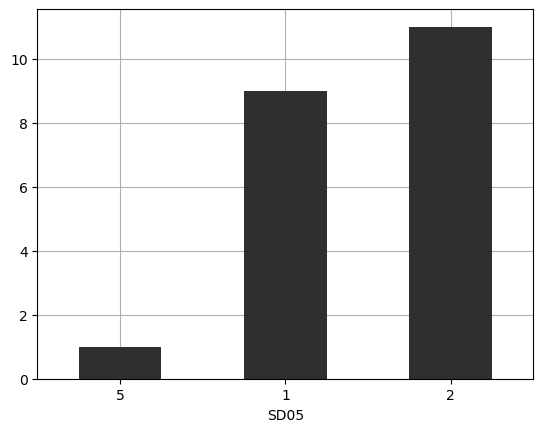

In [14]:
# SD05	Geschlecht (zum kombinieren)	1	Woman
# SD05	Geschlecht (zum kombinieren)	2	Man
# SD05	Geschlecht (zum kombinieren)	3	Transgender
# SD05	Geschlecht (zum kombinieren)	4	Non-binary/non-conforming
# SD05	Geschlecht (zum kombinieren)	5	Prefer not to respond
# SD05	Geschlecht (zum kombinieren)	-9	Not answered

df_study_data['SD05'].value_counts().sort_values().plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

## 2.2. Age

<Axes: xlabel='SD03'>

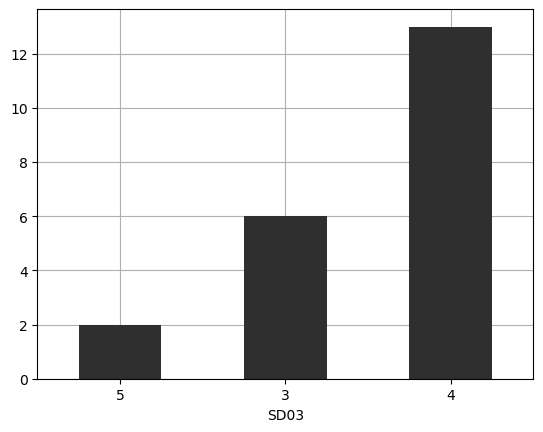

In [15]:
# Alter (Kategorien, 5 Jahre)	3	20 to 30 years old
# Alter (Kategorien, 5 Jahre)	4	30 to 40 years old
# Alter (Kategorien, 5 Jahre)	5	40 to 50 years old
# Alter (Kategorien, 5 Jahre)	6	50 to 60 years old
# Alter (Kategorien, 5 Jahre)	7	60 to 70 years old
# Alter (Kategorien, 5 Jahre)	-9	Not answered

df_study_data['SD03'].value_counts().sort_values().plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [16]:
df_study_data['SD03'].describe()

count    21.000000
mean      3.809524
std       0.601585
min       3.000000
25%       3.000000
50%       4.000000
75%       4.000000
max       5.000000
Name: SD03, dtype: float64

## 2.3. Degree

<Axes: xlabel='SD12'>

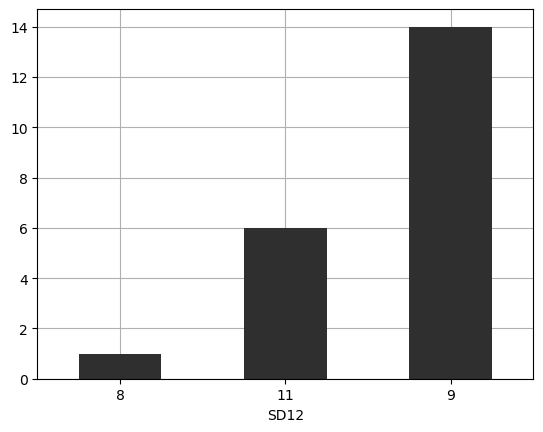

In [17]:
# Beruflicher Bildungsabschluss	1	No schooling completed
# Beruflicher Bildungsabschluss	2	Nursery school to 8th grade
# Beruflicher Bildungsabschluss	3	Some high school, no diploma
# Beruflicher Bildungsabschluss	4	High school graduate, diploma or the equivalent (for example: GED)
# Beruflicher Bildungsabschluss	5	Some college credit, no degree
# Beruflicher Bildungsabschluss	6	Trade/technical/vocational training
# Beruflicher Bildungsabschluss	7	Associate degree
# Beruflicher Bildungsabschluss	8	Bachelor’s degree
# Beruflicher Bildungsabschluss	9	Master’s degree
# Beruflicher Bildungsabschluss	10	Professional degree
# Beruflicher Bildungsabschluss	11	Doctorate degree
# Beruflicher Bildungsabschluss	12	Habilitation
# Beruflicher Bildungsabschluss	13	Other degree
# Beruflicher Bildungsabschluss	-9	Not answered

df_study_data['SD12'].value_counts().sort_values().plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

## 2.4. Years of experience

<Axes: xlabel='SD14'>

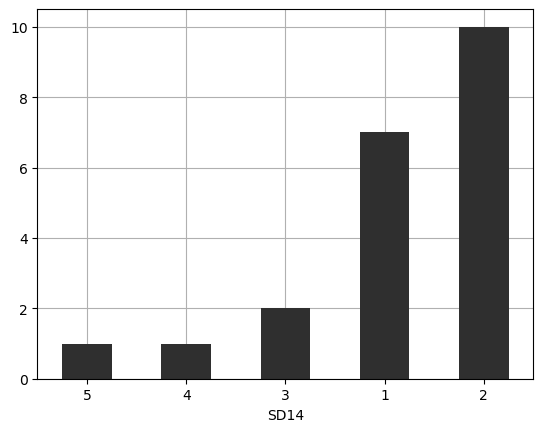

In [18]:
# Years of experience	1	< 5 years of experience
# Years of experience	2	5 - 10 years of experience
# Years of experience	3	10 - 15 years of experience
# Years of experience	4	15 - 20 years of experience
# Years of experience	5	20 - 25 years of experience
# Years of experience	6	25 - 30 years of experience
# Years of experience	7	30 - 35 years of experience
# Years of experience	8	> 35 years of experience
# Years of experience	-9	Not answered

df_study_data['SD14'].value_counts().sort_values().plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [19]:
df_study_data['SD14'].describe()

count    21.000000
mean      2.000000
std       1.048809
min       1.000000
25%       1.000000
50%       2.000000
75%       2.000000
max       5.000000
Name: SD14, dtype: float64

## 2.5. Experience with polar charts

<Axes: xlabel='SD15'>

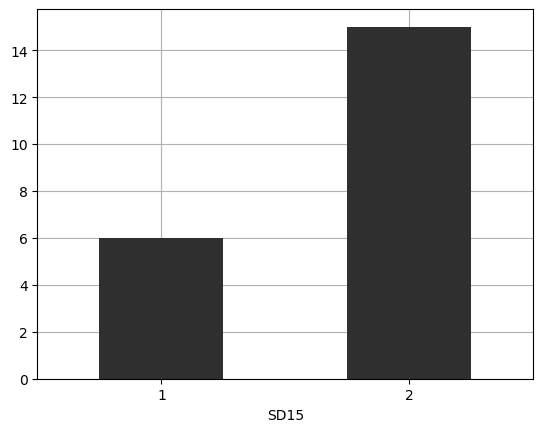

In [20]:
# Polar charts	1	Yes
# Polar charts	2	No
# Polar charts	-9	Not answered

df_study_data['SD15'].value_counts().sort_values().plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

## 2.6. Experience with summary polar diagrams

<Axes: xlabel='SD16'>

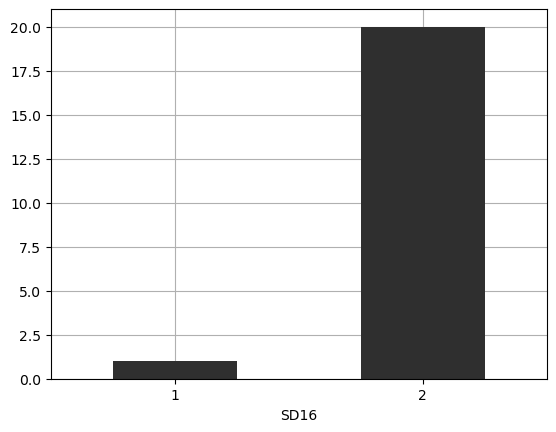

In [21]:
# Summary polar diagrams	1	Yes
# Summary polar diagrams	2	No
# Summary polar diagrams	-9	Not answered

df_study_data['SD16'].value_counts().sort_values().plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

## 2.7. Time to complete
### 2.7.1. Everything

<Axes: >

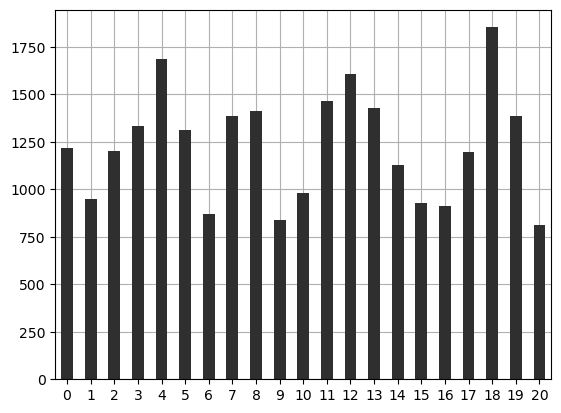

In [22]:
df_study_data['TIME_SUM'].plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [23]:
df_study_data['TIME_SUM'].describe()

count      21.000000
mean     1234.428571
std       294.243704
min       815.000000
25%       947.000000
50%      1217.000000
75%      1414.000000
max      1854.000000
Name: TIME_SUM, dtype: float64

In [24]:
pd.to_datetime(df_study_data['TIME_SUM'], unit='s').describe()

count                     21
mean     1970-01-01 00:20:34
min      1970-01-01 00:13:35
25%      1970-01-01 00:15:47
50%      1970-01-01 00:20:17
75%      1970-01-01 00:23:34
max      1970-01-01 00:30:54
Name: TIME_SUM, dtype: object

In [25]:
# Task 1E - page 5
# Task 1T - page 6
# Task 2E - page 8
# Task 2T - page 9
# Task 3E - page 11
# Task 3T - page 12
# Task 4E - page 14
# Task 4T - page 15

### 2.7.2. Task 1 Training

<Axes: >

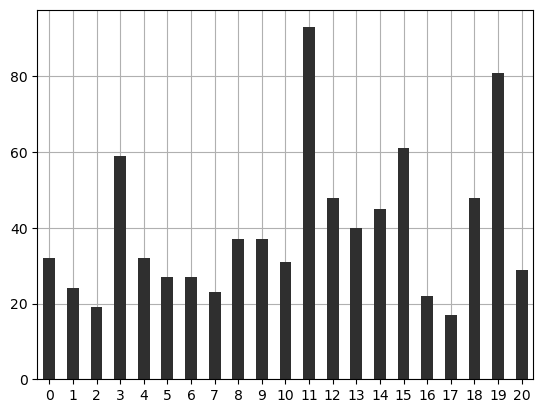

In [26]:
df_study_data['TIME005'].plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [27]:
pd.to_datetime(df_study_data['TIME005'], unit='s').describe()

count                     21
mean     1970-01-01 00:00:39
min      1970-01-01 00:00:17
25%      1970-01-01 00:00:27
50%      1970-01-01 00:00:32
75%      1970-01-01 00:00:48
max      1970-01-01 00:01:33
Name: TIME005, dtype: object

### 2.7.3. Task 1 Test

<Axes: >

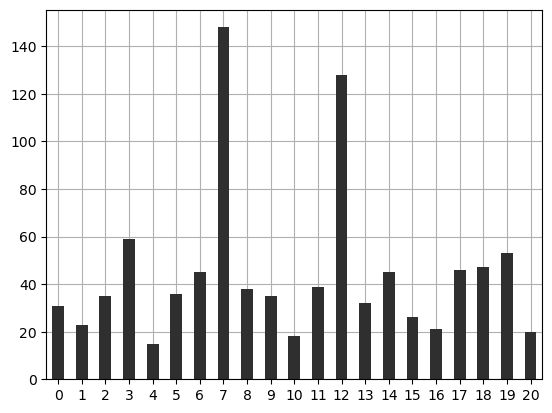

In [28]:
df_study_data['TIME006'].plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [29]:
pd.to_datetime(df_study_data['TIME006'], unit='s').describe()

count                     21
mean     1970-01-01 00:00:44
min      1970-01-01 00:00:15
25%      1970-01-01 00:00:26
50%      1970-01-01 00:00:36
75%      1970-01-01 00:00:46
max      1970-01-01 00:02:28
Name: TIME006, dtype: object

### 2.7.4. Task 2 Training

<Axes: >

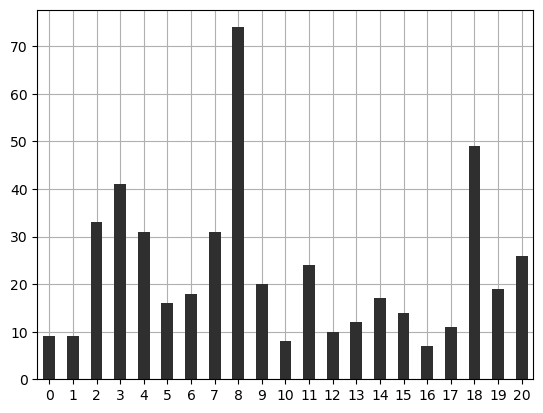

In [30]:
df_study_data['TIME008'].plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [31]:
pd.to_datetime(df_study_data['TIME008'], unit='s').describe()

count                     21
mean     1970-01-01 00:00:22
min      1970-01-01 00:00:07
25%      1970-01-01 00:00:11
50%      1970-01-01 00:00:18
75%      1970-01-01 00:00:31
max      1970-01-01 00:01:14
Name: TIME008, dtype: object

### 2.7.5. Task 2 Test

<Axes: >

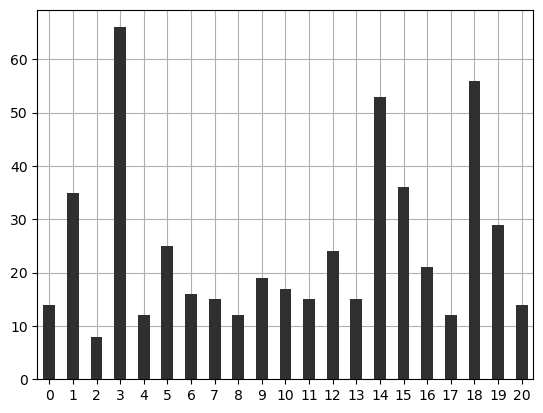

In [32]:
df_study_data['TIME009'].plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [33]:
pd.to_datetime(df_study_data['TIME009'], unit='s').describe()

count                     21
mean     1970-01-01 00:00:24
min      1970-01-01 00:00:08
25%      1970-01-01 00:00:14
50%      1970-01-01 00:00:17
75%      1970-01-01 00:00:29
max      1970-01-01 00:01:06
Name: TIME009, dtype: object

### 2.7.6. Task 3 Training

<Axes: >

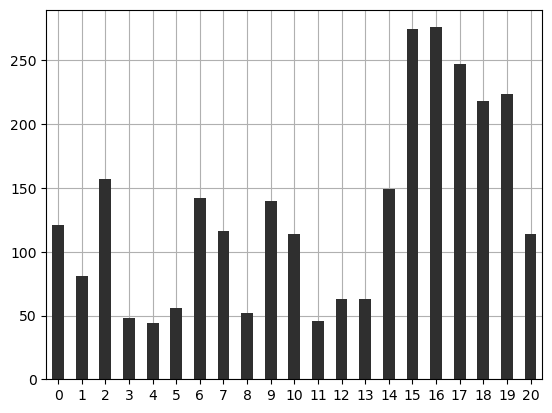

In [34]:
df_study_data['TIME011'].plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [35]:
pd.to_datetime(df_study_data['TIME011'], unit='s').describe()

count                     21
mean     1970-01-01 00:02:10
min      1970-01-01 00:00:44
25%      1970-01-01 00:01:03
50%      1970-01-01 00:01:56
75%      1970-01-01 00:02:37
max      1970-01-01 00:04:36
Name: TIME011, dtype: object

### 2.7.7. Task 3 Test

<Axes: >

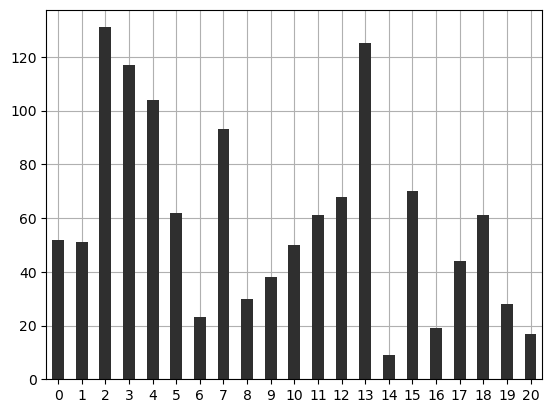

In [36]:
df_study_data['TIME012'].plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [37]:
pd.to_datetime(df_study_data['TIME012'], unit='s').describe()

count                     21
mean     1970-01-01 00:00:59
min      1970-01-01 00:00:09
25%      1970-01-01 00:00:30
50%      1970-01-01 00:00:52
75%      1970-01-01 00:01:10
max      1970-01-01 00:02:11
Name: TIME012, dtype: object

### 2.7.8. Task 4 Training

<Axes: >

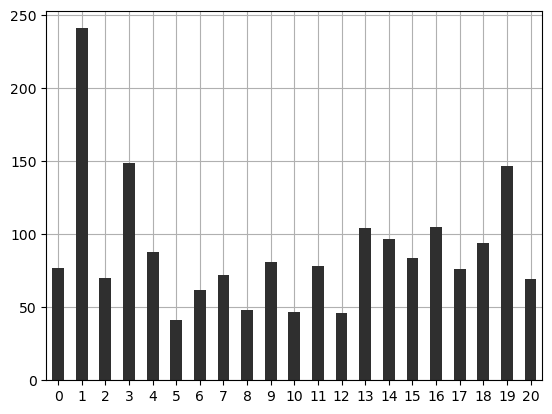

In [38]:
df_study_data['TIME014'].plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [39]:
pd.to_datetime(df_study_data['TIME014'], unit='s').describe()

count                     21
mean     1970-01-01 00:01:29
min      1970-01-01 00:00:41
25%      1970-01-01 00:01:09
50%      1970-01-01 00:01:18
75%      1970-01-01 00:01:37
max      1970-01-01 00:04:01
Name: TIME014, dtype: object

### 2.7.9. Task 4 Test

<Axes: >

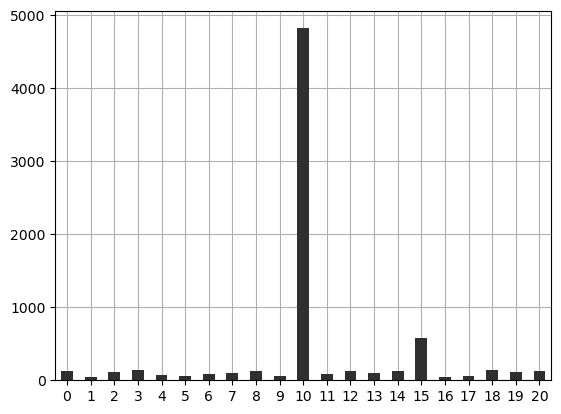

In [40]:
df_study_data['TIME015'].plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [41]:
pd.to_datetime(df_study_data['TIME015'], unit='s').describe()

count                     21
mean     1970-01-01 00:05:45
min      1970-01-01 00:00:44
25%      1970-01-01 00:01:18
50%      1970-01-01 00:01:50
75%      1970-01-01 00:02:08
max      1970-01-01 01:20:21
Name: TIME015, dtype: object

### 2.7.10. Cumulative

- "TS04","TASK1 E","NOMINAL","SELECTION","Which model is closest to the reference model?"
- "TS07","TASK2 E","NOMINAL","SELECTION","How many clusters are there, not counting the reference model?"
- "TS10","TASK3 E","NOMINAL","SELECTION","Select <u>Cluster 1</u> using the legend or overview. Which individual model at the center of that cluster has the middle/median variation of information (VI)?"
- "TS13","TASK4 E","NOMINAL","SELECTION","Select models <u>Wine_4</u> and <u>Wine_17</u>. Check the tooltip and Cartesian-linking plot. What is the approximate sum of their entropies?"
- "TS05","TASK1 T","NOMINAL","SELECTION","Which 3 models are the furthest from the reference model?"
- "TS08","TASK2 T","NOMINAL","SELECTION","How many models are in <u>Cluster 4</u>?"
- "TS11","TASK3 T","NOMINAL","SELECTION","What model from <u>Cluster 1</u> is furthest from <u>Cluster 5</u>?"
- "TS14","TASK4 T","NOMINAL","SELECTION","Select <u>Cluster 3</u> and <u>Cluster 5</u>. What are the ranges of variation of information (VI) within these two clusters? Provide the minimum and maximum VI values for these clusters, starting from smallest to largest."

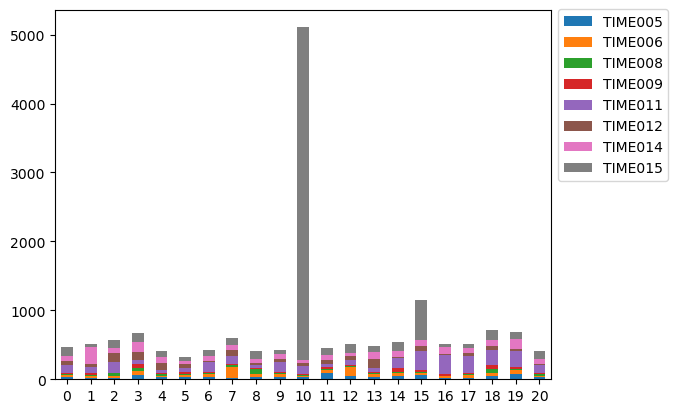

In [42]:
ax = df_study_data.plot(
    y=['TIME005', 'TIME006', 'TIME008', 'TIME009', 'TIME011', 'TIME012',
       'TIME014', 'TIME015'],
    kind="bar", rot=0, stacked=True)
_ = ax.legend(bbox_to_anchor=(1, 1.02), loc='upper left')

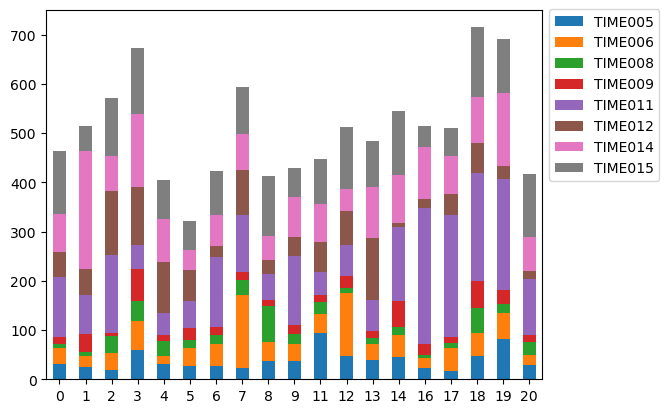

In [43]:
ax = df_study_data.drop([10, 15]).plot(  # We drop two outliers
    y=['TIME005', 'TIME006', 'TIME008', 'TIME009', 'TIME011', 'TIME012',
       'TIME014', 'TIME015'],
    kind="bar", rot=0, stacked=True)
_ = ax.legend(bbox_to_anchor=(1, 1.02), loc='upper left')

## 2.8. SGL Scale

<Axes: >

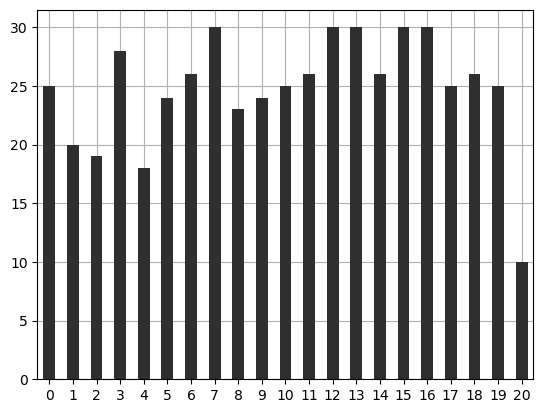

In [44]:
df_study_data['SGL_Score'] = df_study_data[[
    'SD18_01', 'SD18_02', 'SD18_03', 'SD18_04', 'SD18_05']].sum(axis=1)

df_study_data['SGL_Score'].plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [45]:
df_study_data['SGL_Score'].describe()

count    21.000000
mean     24.761905
std       4.887788
min      10.000000
25%      24.000000
50%      25.000000
75%      28.000000
max      30.000000
Name: SGL_Score, dtype: float64

## 2.9. SUS Evaluation

In [46]:
df_sus_score = df_study_data[[
    'CASE', 'SGL_Score', 'OU01_01', 'OU01_02', 'OU01_03', 'OU01_04', 'OU01_05', 'OU01_06',
    'OU01_07', 'OU01_08', 'OU01_09', 'OU01_10']]
df_sus_score

,CASE,SGL_Score,OU01_01,OU01_02,OU01_03,OU01_04,OU01_05,OU01_06,OU01_07,OU01_08,OU01_09,OU01_10
0,147,25,2,3,4,2,3,1,3,4,4,3
1,148,20,2,5,1,2,1,5,1,5,2,5
2,149,19,3,2,4,3,4,2,4,2,3,3
3,150,28,1,3,2,1,3,2,1,3,3,5
4,152,18,5,1,5,1,5,1,5,1,5,1
5,153,24,5,2,4,2,4,1,3,1,4,2
6,154,26,2,4,2,1,3,1,2,3,4,1
7,157,30,5,1,5,4,5,1,3,1,5,2
8,158,23,3,2,4,1,4,2,4,2,5,3
9,160,24,2,3,3,4,3,3,4,3,2,3


In [47]:
# Calculating SUS scores in general and stratified by expertise
list_positive_sus_questions = ['OU01_01', 'OU01_03', 'OU01_05', 'OU01_07',
                               'OU01_09']
list_negative_sus_questions = ['OU01_02', 'OU01_04', 'OU01_06', 'OU01_08',
                               'OU01_10']
list_exclude_cols = ['CASE', 'SGL_Score']

list_cols_to_subtract = [col for col in df_sus_score.columns
    if col not in list_exclude_cols]

df_sus_score[list_cols_to_subtract] = df_sus_score[list_cols_to_subtract] - 1
series_sus_score = 2.5 * (
    20 +
    df_sus_score.set_index(['CASE', 'SGL_Score'])[
        list_positive_sus_questions].sum(axis=1) -
    df_sus_score.set_index(['CASE', 'SGL_Score'])[
        list_negative_sus_questions].sum(axis=1))

df_study_data['SUS_Score'] = series_sus_score.values
df_study_data

,CASE,SERIAL,REF,QUESTNNR,MODE,STARTED,IN02,IN02_01,NA04,NA04_01,...,LASTDATA,FINISHED,Q_VIEWER,LASTPAGE,MAXPAGE,MISSING,MISSREL,TIME_RSI,SGL_Score,SUS_Score
0,147,NaN,NaN,base,interview,2024-07-19 12:42:44,1,2,1,2,...,2024-07-19 13:03:01,1,0,16,16,0,0,1.53,25,57.5
1,148,NaN,NaN,base,interview,2024-07-19 13:18:06,1,2,1,2,...,2024-07-19 13:36:36,1,0,16,16,3,2,1.50,20,12.5
2,149,NaN,NaN,base,interview,2024-07-19 14:17:46,1,2,1,2,...,2024-07-19 14:37:49,1,0,16,16,3,2,1.28,19,65.0
3,150,NaN,NaN,base,interview,2024-07-19 15:57:51,1,2,1,2,...,2024-07-19 16:51:38,1,0,16,16,0,0,1.00,28,40.0
4,152,NaN,NaN,base,interview,2024-07-22 10:02:46,1,2,1,2,...,2024-07-22 10:37:51,1,0,16,16,0,0,1.02,18,100.0
5,153,NaN,NaN,base,interview,2024-07-22 11:12:54,1,2,1,2,...,2024-07-22 11:41:24,1,0,16,16,3,2,1.20,24,80.0
6,154,NaN,NaN,base,interview,2024-07-22 12:24:01,1,2,1,2,...,2024-07-22 12:38:34,1,0,16,16,3,2,1.42,26,57.5
7,157,NaN,NaN,base,interview,2024-07-22 15:48:47,1,2,1,2,...,2024-07-22 16:19:02,1,0,16,16,0,0,0.96,30,85.0
8,158,NaN,NaN,base,interview,2024-07-23 16:33:29,1,2,1,2,...,2024-07-23 16:57:59,1,0,16,16,0,0,1.00,23,75.0
9,160,NaN,NaN,base,interview,2024-07-24 10:11:49,1,2,1,2,...,2024-07-24 10:25:52,1,0,16,16,3,2,1.60,24,45.0


<Axes: >

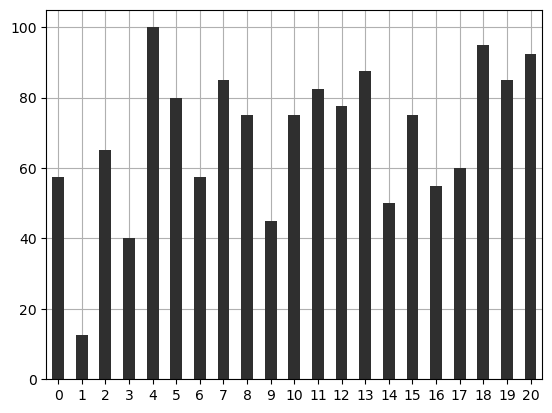

In [48]:
df_study_data['SUS_Score'].plot(
    kind='bar', rot=0, color=_COLOR_PLOT, grid=True)

In [49]:
# Let's get an average and median scores
float_sus_general_mean = df_study_data['SUS_Score'].mean()
float_sus_general_median = df_study_data['SUS_Score'].median()

float_sus_experts_mean = df_study_data[df_study_data['SGL_Score']
    > 28]['SUS_Score'].mean()
float_sus_experts_median = df_study_data[df_study_data['SGL_Score']
    > 28]['SUS_Score'].median()

float_sus_non_experts_mean = df_study_data[df_study_data['SGL_Score']
    <= 28]['SUS_Score'].mean()
float_sus_non_experts_median = df_study_data[df_study_data['SGL_Score']
    <= 28]['SUS_Score'].median()

print('General: mean = ', float_sus_general_mean, ', median =',
      float_sus_general_median)
print('Experts: mean = ', float_sus_experts_mean, ', median =',
      float_sus_experts_median)
print('Non-Experts: mean = ', float_sus_non_experts_mean, ', median =',
      float_sus_non_experts_median)

General: mean =  69.16666666666667 , median = 75.0
Experts: mean =  76.0 , median = 77.5
Non-Experts: mean =  67.03125 , median = 70.0


In [50]:
list_questions = ['OU01_01', 'OU01_02', 'OU01_03', 'OU01_04', 'OU01_05',
                  'OU01_06', 'OU01_07', 'OU01_08', 'OU01_09', 'OU01_10']

dict_sus_questions = {
    'OU01_01': 'I think that I would like to use this system frequently.',
    'OU01_02': 'I found the system unnecessarily complex.',
    'OU01_03': 'I thought the system was easy to use.',
    'OU01_04': 'I think that I would need the support of a technical person to be able to use this system.',  # noqa
    'OU01_05': 'I found the various functions in this system were well integrated.',  # noqa
    'OU01_06': 'I thought there was too much inconsistency in this system.',
    'OU01_07': 'I would imagine that most people would learn to use this system very quickly.',  # noqa
    'OU01_08': 'I found the system very cumbersome to use.',
    'OU01_09': 'I felt very confident using the system.',
    'OU01_10': 'I needed to learn a lot of things before I could get going with this system.'  # noqa
}

df_sus_evaluation = df_study_data[['OU01_01', 'OU01_02', 'OU01_03', 'OU01_04',
                                   'OU01_05', 'OU01_06', 'OU01_07', 'OU01_08',
                                   'OU01_09', 'OU01_10']]
df_sus_evaluation_long = df_sus_evaluation.melt()
df_sus_evaluation_long['Question'] = [
    dict_sus_questions[string_id] for string_id in
    df_sus_evaluation_long['variable']]
df_sus_evaluation_long["Question_wrapped"] = df_sus_evaluation_long[
    "Question"].str.wrap(width=20, max_lines=4, placeholder = " ... ")
df_sus_evaluation_long["Question_wrapped"] = df_sus_evaluation_long[
    "Question_wrapped"].str.replace('\n', '<br>')
df_sus_evaluation_long

,variable,value,Question,Question_wrapped
0,OU01_01,2,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
1,OU01_01,2,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
2,OU01_01,3,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
3,OU01_01,1,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
4,OU01_01,5,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
...,...,...,...,...
205,OU01_10,1,I needed to learn a lot of things before I cou...,I needed to learn a<br>lot of things before<br...
206,OU01_10,2,I needed to learn a lot of things before I cou...,I needed to learn a<br>lot of things before<br...
207,OU01_10,1,I needed to learn a lot of things before I cou...,I needed to learn a<br>lot of things before<br...
208,OU01_10,2,I needed to learn a lot of things before I cou...,I needed to learn a<br>lot of things before<br...


/var/folders/lt/rbb0s8nn4wzbjftxx8s6bqx40000gp/T/ipykernel_13066/2968467154.py:23: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  chart_sus.write_image(os.path.join(path_study_data_results, 'SUS.pdf'))


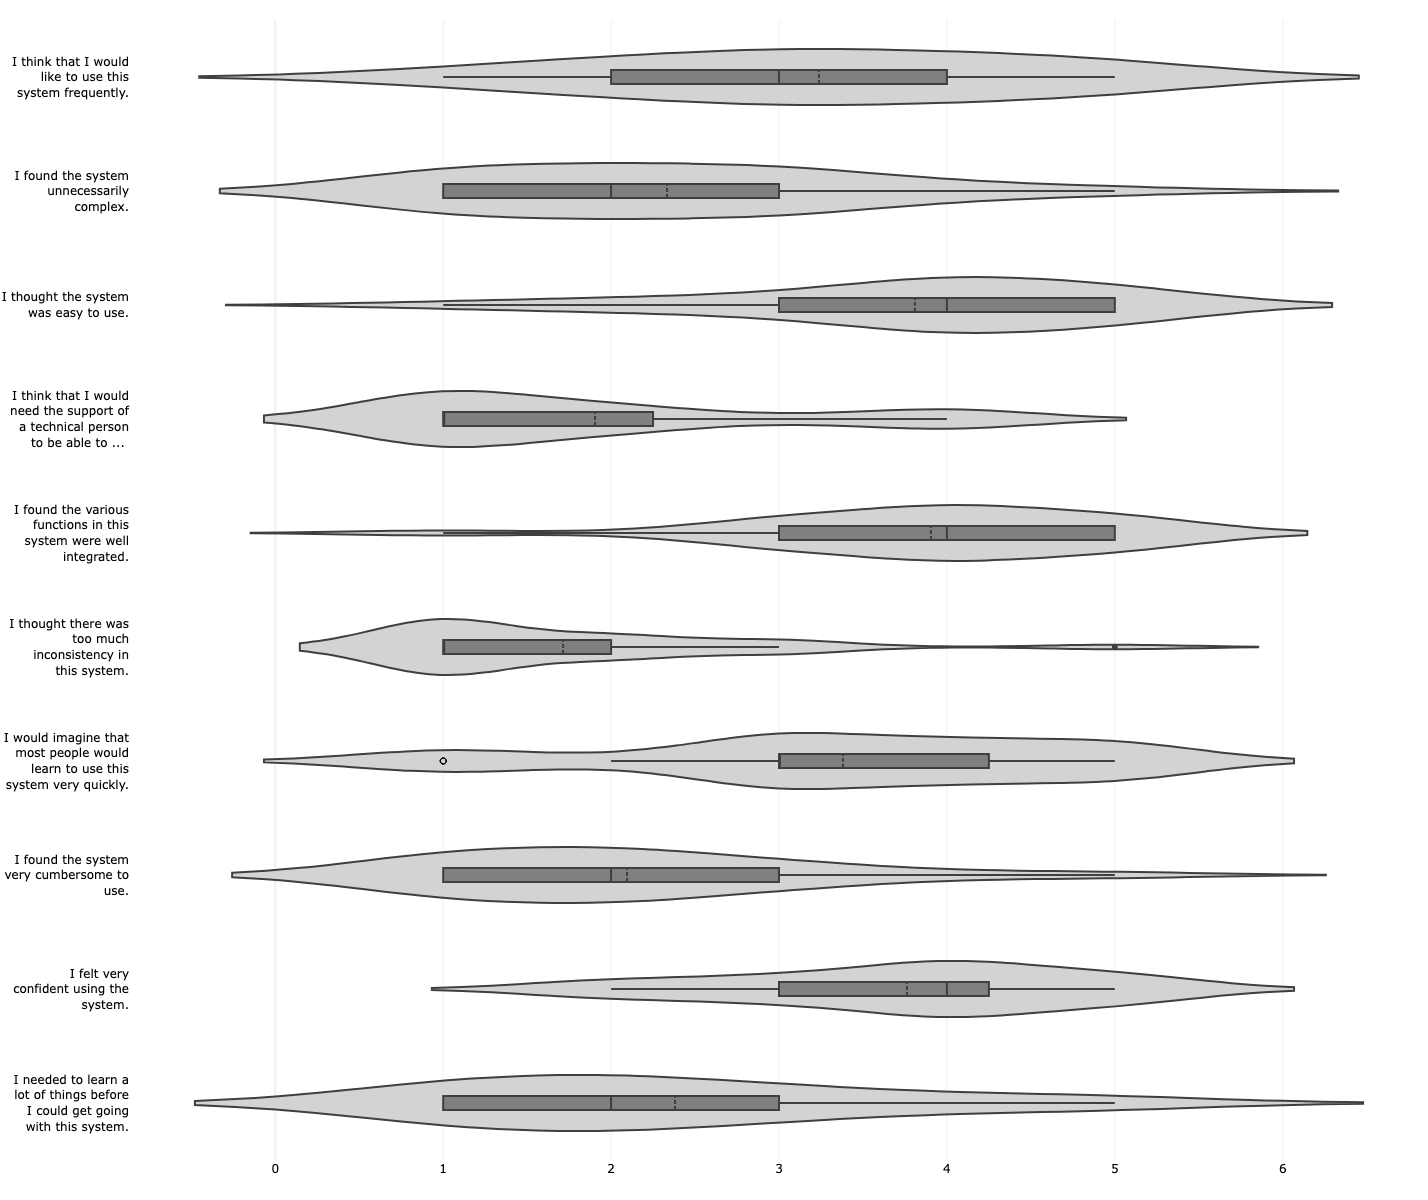

In [51]:
chart_sus = go.Figure()

for string_question in list_questions[::-1]:
    chart_sus.add_trace(go.Violin(
        y=df_sus_evaluation_long['Question_wrapped'][
            df_sus_evaluation_long['variable'] == string_question],
        x=df_sus_evaluation_long['value'][
            df_sus_evaluation_long['variable'] == string_question],
        name=dict_sus_questions[string_question],
        box_visible=True,
        meanline_visible=True,
        fillcolor = '#d3d3d3',
        line_color = '#3f3f3f',
        marker_line_outliercolor= 'black',
        box_fillcolor = 'grey'))

chart_sus.update_traces(orientation='h')
chart_sus.update_layout(height=1200, width=800, showlegend=False,
                        template='plotly_white',
                        margin=dict(l=20, r=0, t=20, b=40))
chart_sus.update_yaxes(tickfont_color='black')
chart_sus.update_xaxes(tickfont_color='black')
chart_sus.write_image(os.path.join(path_study_data_results, 'SUS.pdf'))
chart_sus.show()

In [52]:
df_experts = df_study_data[df_study_data['SGL_Score'] > 28.0]

df_sus_evaluation_experts = df_experts[[
    'OU01_01', 'OU01_02', 'OU01_03', 'OU01_04',
    'OU01_05', 'OU01_06', 'OU01_07', 'OU01_08',
    'OU01_09', 'OU01_10']]
df_sus_evaluation_experts_long = df_sus_evaluation_experts.melt()
df_sus_evaluation_experts_long['Question'] = [
    dict_sus_questions[string_id] for string_id in
    df_sus_evaluation_experts_long['variable']]
df_sus_evaluation_experts_long["Question_wrapped"] = df_sus_evaluation_experts_long[  # noqa
    "Question"].str.wrap(width=20, max_lines=4, placeholder = " ... ")
df_sus_evaluation_experts_long["Question_wrapped"] = df_sus_evaluation_experts_long[
    "Question_wrapped"].str.replace('\n', '<br>')
df_sus_evaluation_experts_long

,variable,value,Question,Question_wrapped
0,OU01_01,5,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
1,OU01_01,5,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
2,OU01_01,3,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
3,OU01_01,4,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
4,OU01_01,1,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
5,OU01_02,1,I found the system unnecessarily complex.,I found the system<br>unnecessarily<br>complex.
6,OU01_02,4,I found the system unnecessarily complex.,I found the system<br>unnecessarily<br>complex.
7,OU01_02,2,I found the system unnecessarily complex.,I found the system<br>unnecessarily<br>complex.
8,OU01_02,3,I found the system unnecessarily complex.,I found the system<br>unnecessarily<br>complex.
9,OU01_02,3,I found the system unnecessarily complex.,I found the system<br>unnecessarily<br>complex.


In [53]:
df_non_experts = df_study_data[df_study_data['SGL_Score'] <= 28.0]

df_sus_evaluation_non_experts = df_non_experts[[
    'OU01_01', 'OU01_02', 'OU01_03', 'OU01_04',
    'OU01_05', 'OU01_06', 'OU01_07', 'OU01_08',
    'OU01_09', 'OU01_10']]
df_sus_evaluation_non_experts_long = df_sus_evaluation_non_experts.melt()
df_sus_evaluation_non_experts_long['Question'] = [
    dict_sus_questions[string_id] for string_id in
    df_sus_evaluation_non_experts_long['variable']]
df_sus_evaluation_non_experts_long["Question_wrapped"] = df_sus_evaluation_non_experts_long[  # noqa
    "Question"].str.wrap(width=20, max_lines=4, placeholder = " ... ")
df_sus_evaluation_non_experts_long["Question_wrapped"] = df_sus_evaluation_non_experts_long[  # noqa
    "Question_wrapped"].str.replace('\n', '<br>')
df_sus_evaluation_non_experts_long

,variable,value,Question,Question_wrapped
0,OU01_01,2,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
1,OU01_01,2,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
2,OU01_01,3,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
3,OU01_01,1,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
4,OU01_01,5,I think that I would like to use this system f...,I think that I would<br>like to use this<br>sy...
...,...,...,...,...
155,OU01_10,4,I needed to learn a lot of things before I cou...,I needed to learn a<br>lot of things before<br...
156,OU01_10,2,I needed to learn a lot of things before I cou...,I needed to learn a<br>lot of things before<br...
157,OU01_10,1,I needed to learn a lot of things before I cou...,I needed to learn a<br>lot of things before<br...
158,OU01_10,2,I needed to learn a lot of things before I cou...,I needed to learn a<br>lot of things before<br...


/var/folders/lt/rbb0s8nn4wzbjftxx8s6bqx40000gp/T/ipykernel_13066/3238314677.py:23: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  chart_sus_expert.write_image(os.path.join(path_study_data_results,


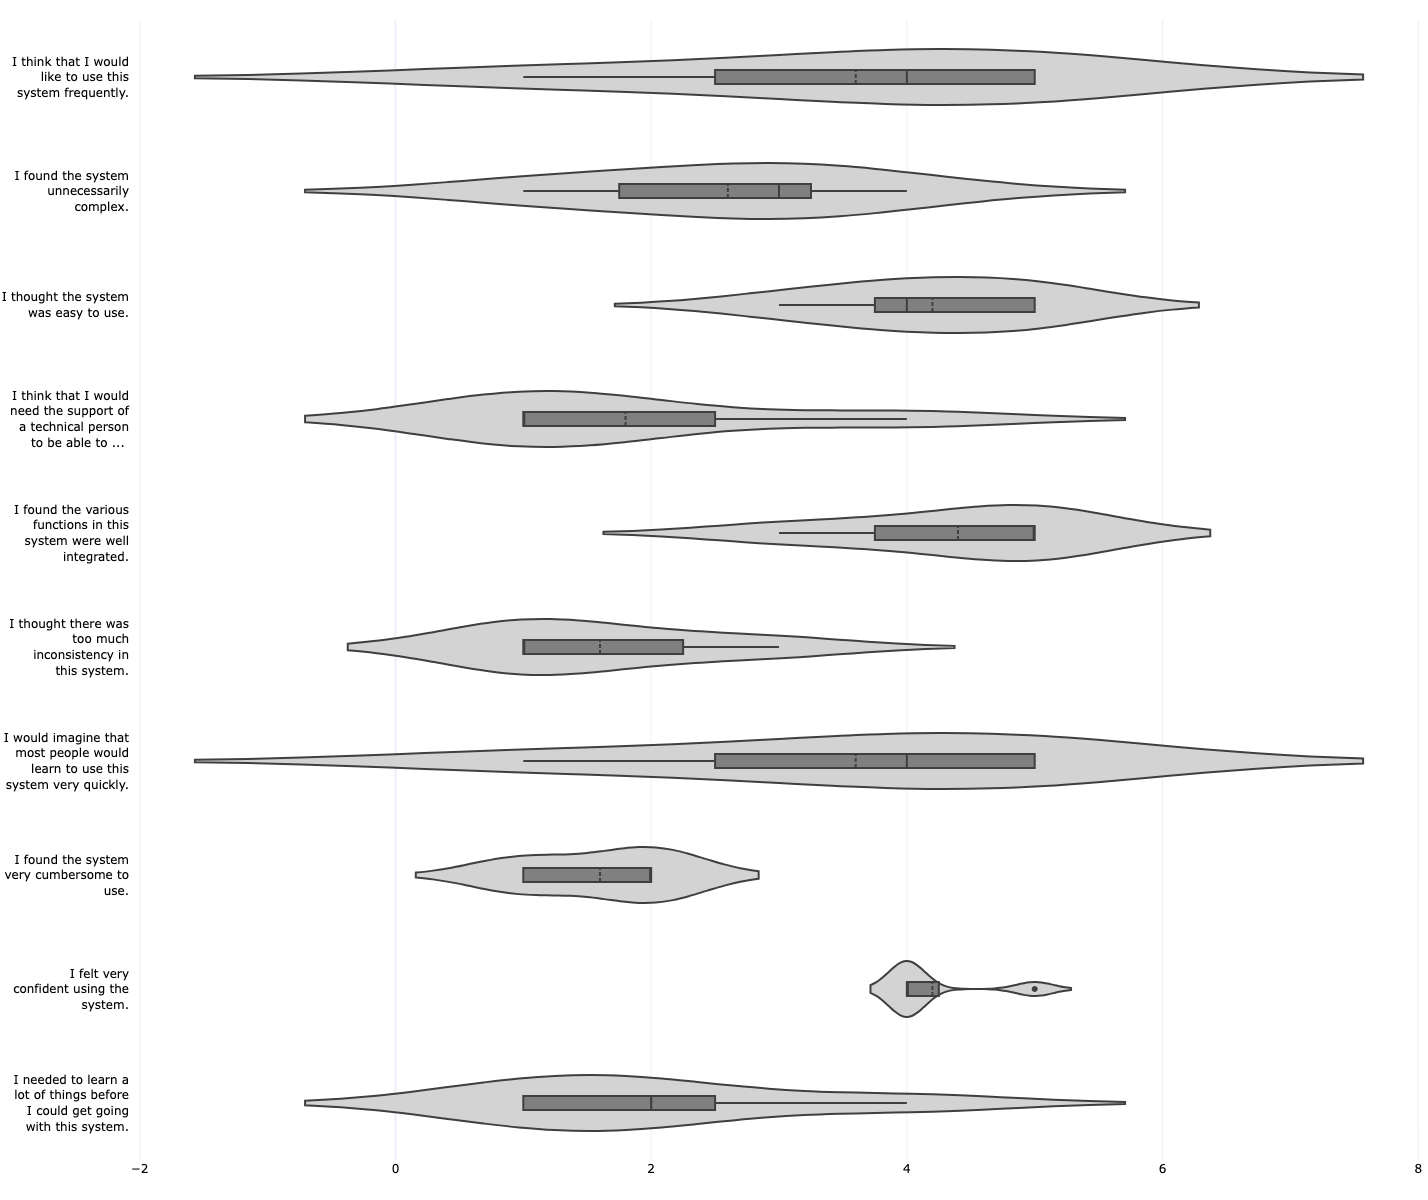

In [54]:
chart_sus_expert = go.Figure()

for string_question in list_questions[::-1]:
    chart_sus_expert.add_trace(go.Violin(
        y=df_sus_evaluation_experts_long['Question_wrapped'][
            df_sus_evaluation_experts_long['variable'] == string_question],
        x=df_sus_evaluation_experts_long['value'][
            df_sus_evaluation_experts_long['variable'] == string_question],
        name=dict_sus_questions[string_question],
        box_visible=True,
        meanline_visible=True,
        fillcolor = '#d3d3d3',
        line_color = '#3f3f3f',
        marker_line_outliercolor= 'black',
        box_fillcolor = 'grey'))

chart_sus_expert.update_traces(orientation='h')
chart_sus_expert.update_layout(height=1200, width=800, showlegend=False,
                               template='plotly_white',
                               margin=dict(l=20, r=0, t=20, b=40))
chart_sus_expert.update_yaxes(tickfont_color='black')
chart_sus_expert.update_xaxes(tickfont_color='black')
chart_sus_expert.write_image(os.path.join(path_study_data_results,
                                          'SUS_expert.pdf'))
chart_sus_expert.show()

/var/folders/lt/rbb0s8nn4wzbjftxx8s6bqx40000gp/T/ipykernel_13066/2395170533.py:23: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  chart_sus_non_expert.write_image(os.path.join(path_study_data_results,


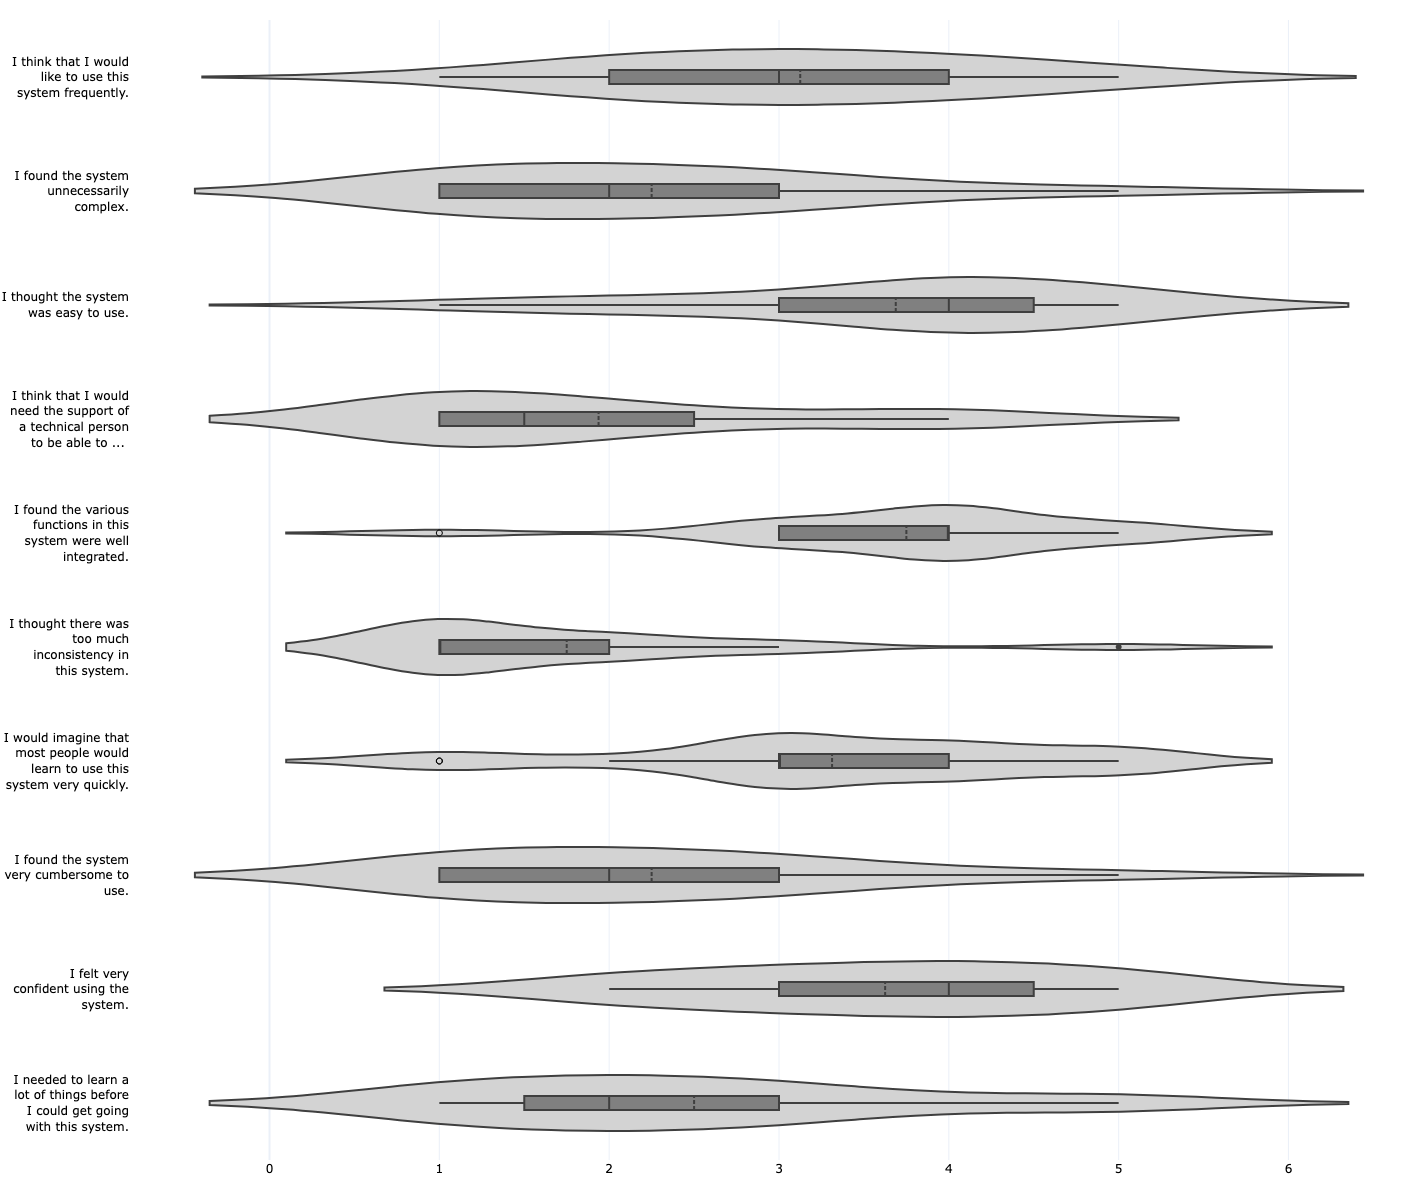

In [55]:
chart_sus_non_expert = go.Figure()

for string_question in list_questions[::-1]:
    chart_sus_non_expert.add_trace(go.Violin(
        y=df_sus_evaluation_non_experts_long['Question_wrapped'][
            df_sus_evaluation_non_experts_long['variable'] == string_question],
        x=df_sus_evaluation_non_experts_long['value'][
            df_sus_evaluation_non_experts_long['variable'] == string_question],
        name=dict_sus_questions[string_question],
        box_visible=True,
        meanline_visible=True,
        fillcolor = '#d3d3d3',
        line_color = '#3f3f3f',
        marker_line_outliercolor= 'black',
        box_fillcolor = 'grey'))

chart_sus_non_expert.update_traces(orientation='h')
chart_sus_non_expert.update_layout(height=1200, width=800, showlegend=False,
                                   template='plotly_white',
                                   margin=dict(l=20, r=0, t=20, b=40))
chart_sus_non_expert.update_yaxes(tickfont_color='black')
chart_sus_non_expert.update_xaxes(tickfont_color='black')
chart_sus_non_expert.write_image(os.path.join(path_study_data_results,
                                              'SUS_non_expert.pdf'))
chart_sus_non_expert.show()

## 2.10. Optional Feedback

In [56]:
for i, str_text in enumerate(df_study_data['OU03_01'].to_list()):
    if not isinstance(str_text, float):
        print(str(i) + ': ' + str_text + '\n')

0: I think the idea is very good and I comparing the proximity via the radial scale is easier than looking at barplots. However, I think the part with the clustering and comparing the clusters could be improved. It felt a little clumsy and it took some time to select the clusters I was interested in. 
Maybe you could add a function that let the user select the cluster with the legend? I think it's also a little confusing that points from different clusters have different colors. It would maybe be easiert to follow if all points of Cluster 1 were shown in different shades of blue. 

3: the reference model is not always shown whenever the user select subcategories

4: everything looks well-developed and quite straightforward to follow. However, the figures in the explanation page seem to appear slightly smaller in laptop, though they are still visible. 

7: I missed a button or clear instructions on resetting the page and returning to the initial state.

8: I had an issue where some of t

## 2.11. Expertise

In [57]:
# "SD13","Field of expertise: Residual option (negative) or number of selected options","METRIC","SYSTEM","What is your field of expertise? Multiple choices are allowed."
# "SD13_01","Field of expertise: Business and Management","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_02","Field of expertise: Engineering and Technology","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_03","Field of expertise: Healthcare and Medicine","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_04","Field of expertise: Education and Teaching","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_05","Field of expertise: Arts and Design","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_06","Field of expertise: Law and Legal Services","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_07","Field of expertise: Finance and Economics","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_08","Field of expertise: Information Technology","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_09","Field of expertise: Sciences (Physical, Life, and Social)","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_10","Field of expertise: Media and Communications","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_11","Field of expertise: Agriculture and Environmental Studies","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_12","Field of expertise: Public Service and Administration","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_13","Field of expertise: Hospitality and Tourism","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_14","Field of expertise: Manufacturing and Construction","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."
# "SD13_15","Field of expertise: Social Services and Counseling","DICHOTOMOUS","CHECKBOX","What is your field of expertise? Multiple choices are allowed."

df_expertise_data = df_study_data[[
    'SD13', 'SD13_01', 'SD13_02', 'SD13_03', 'SD13_04', 'SD13_05', 'SD13_06',
    'SD13_07', 'SD13_08', 'SD13_09', 'SD13_10', 'SD13_11', 'SD13_12',
    'SD13_13', 'SD13_14', 'SD13_15']].copy()
df_expertise_data

,SD13,SD13_01,SD13_02,SD13_03,SD13_04,SD13_05,SD13_06,SD13_07,SD13_08,SD13_09,SD13_10,SD13_11,SD13_12,SD13_13,SD13_14,SD13_15
0,2,1,1,1,1,1,1,1,2,2,1,1,1,1,1,1
1,2,1,1,1,1,1,1,1,2,2,1,1,1,1,1,1
2,2,1,1,2,1,1,1,1,1,2,1,1,1,1,1,1
3,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1
4,2,1,1,2,1,1,1,1,2,1,1,1,1,1,1,1
5,1,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1
6,6,2,2,2,2,1,1,1,1,2,1,1,2,1,1,1
7,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1
8,2,1,1,1,1,1,1,1,2,2,1,1,1,1,1,1
9,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1


In [58]:
df_expertise_data['SD13'].value_counts()

SD13
1    11
2     9
6     1
Name: count, dtype: int64

In [59]:
df_expertise_data.drop('SD13', axis=1).replace({1: 0, 2:1}).sum(
    axis=0).sort_values(ascending=False)

SD13_09    14
SD13_08    10
SD13_02     5
SD13_03     3
SD13_01     1
SD13_04     1
SD13_12     1
SD13_05     0
SD13_06     0
SD13_07     0
SD13_10     0
SD13_11     0
SD13_13     0
SD13_14     0
SD13_15     0
dtype: int64

In [60]:
df_expertise_data.drop('SD13', axis=1).replace({1: 0, 2:1}).sum(
    axis=0).sort_values(ascending=False).sum(axis=0)

np.int64(35)

# 3. Hypothesis Testing

## 3.1. Accuracy

In [61]:
df_study_data = pd.read_csv(
    path_study_data, encoding='utf-16',
    usecols=['TS04','TS07','TS10','TS13','TS05','TS08','TS11','TS14',
             'SD18_01', 'SD18_02', 'SD18_03', 'SD18_04', 'SD18_05'])
df_study_data = df_study_data.drop(index=[0])
df_study_data.reset_index(drop=True, inplace=True)
df_study_data[[
    'SD18_01', 'SD18_02', 'SD18_03', 'SD18_04',
    'SD18_05']] = df_study_data[[
    'SD18_01', 'SD18_02', 'SD18_03', 'SD18_04', 'SD18_05']].astype(float)
df_study_data['SGL_Score'] = df_study_data[[
    'SD18_01', 'SD18_02', 'SD18_03', 'SD18_04', 'SD18_05']].sum(axis=1)

df_study_data["Experience"] = df_study_data["SGL_Score"] > 28

In [62]:
df_study_data['TS04'] = df_study_data['TS04'].replace(
    {'4': 'Right', '1': 'Wrong', '2': 'Wrong',
     '3': 'Wrong', '5': 'Wrong', '6': 'Wrong'})
df_study_data['TS05'] = df_study_data['TS05'].replace(
    {'5': 'Right', '1': 'Wrong', '2': 'Wrong',
     '3': 'Wrong', '4': 'Wrong', '6': 'Wrong'})
df_study_data['TS07'] = df_study_data['TS07'].replace(
    {'5': 'Right', '1': 'Wrong', '2': 'Wrong',
     '3': 'Wrong', '4': 'Wrong', '6': 'Wrong'})
df_study_data['TS08'] = df_study_data['TS08'].replace(
    {'3': 'Right', '1': 'Wrong', '2': 'Wrong',
     '4': 'Wrong', '5': 'Wrong', '6': 'Wrong'})
df_study_data['TS10'] = df_study_data['TS10'].replace(
    {'1': 'Right', '5': 'Wrong', '2': 'Wrong',
     '3': 'Wrong', '4': 'Wrong', '6': 'Wrong'})
df_study_data['TS11'] = df_study_data['TS11'].replace(
    {'6': 'Right', '1': 'Wrong', '2': 'Wrong',
     '4': 'Wrong', '5': 'Wrong', '3': 'Wrong'})
df_study_data['TS13'] = df_study_data['TS13'].replace(
    {'3': 'Right', '1': 'Wrong', '2': 'Wrong',
     '4': 'Wrong', '5': 'Wrong', '6': 'Wrong'})
df_study_data['TS14'] = df_study_data['TS14'].replace(
    {'5': 'Right', '1': 'Wrong', '2': 'Wrong',
     '3': 'Wrong', '4': 'Wrong', '6': 'Wrong'})

### Train

In [63]:
df_train = df_study_data.melt(
    id_vars=['Experience'], value_vars=['TS04', 'TS07', 'TS10', 'TS13'],
    var_name='Original_Column',
    value_name='Answer')
df_train_expert = df_train[df_train["Experience"] == True]
print(df_train_expert['Answer'].value_counts()['Right'])
df_train_novice = df_train[df_train["Experience"] == False]
print(df_train_novice['Answer'].value_counts()['Right'])
print(df_train_novice['Answer'].value_counts()['Wrong'])

20
62
2


In [64]:
data = {
    'Name': ['Expert', 'Non-Expert'],
    'Percentage': [100, 96.88,],
}

df = pd.DataFrame(data)
print(df)


         Name  Percentage
0      Expert      100.00
1  Non-Expert       96.88


### Test

In [65]:
df_test = df_study_data.melt(
    id_vars=['Experience'], value_vars=['TS05', 'TS08', 'TS11', 'TS14'],
    var_name='Original_Column',
    value_name='Answer')
df_test_expert = df_test[df_test["Experience"] == True]
print(df_test_expert['Answer'].value_counts()['Right'])
print(df_test_expert['Answer'].value_counts()['Wrong'])
df_test_novice = df_test[df_test["Experience"] == False]
print(df_test_novice['Answer'].value_counts()['Right'])
print(df_test_novice['Answer'].value_counts()['Wrong'])

18
2
62
2


### Results

/var/folders/lt/rbb0s8nn4wzbjftxx8s6bqx40000gp/T/ipykernel_13066/156260640.py:47: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(path_study_data_results,


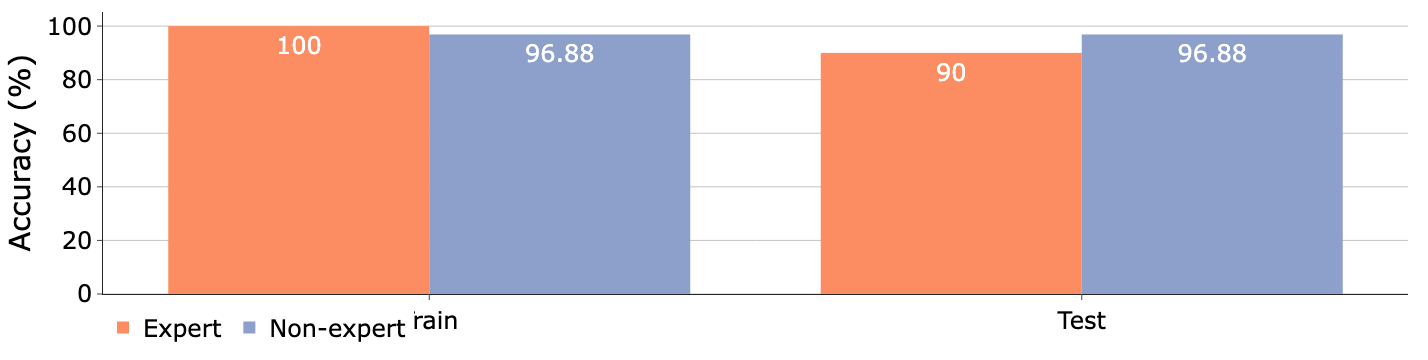

In [66]:
width = 500
animals=['Train', 'Test']
y_expert = [100, 90]
y_nonexpert = [96.88, 96.88]

fig = go.Figure(data=[
    go.Bar(name='Expert', x=animals, y=y_expert, text=y_expert,
           marker_color='#FC8D62'),
    go.Bar(name='Non-expert', x=animals, y=y_nonexpert, text=y_nonexpert,
           marker_color='#8DA0CB')
])
fig.update_traces(textposition='inside',
                #   texttemplate='%{text:.2s}',
                  textfont_size=24,
                  textangle=0,
                  marker_line_width = 0,
                  textfont_color='white',
                  )
fig.update_xaxes(showgrid=False)
fig.update_yaxes(zeroline=True, zerolinewidth=1, zerolinecolor='#C3C3C3',
                 showgrid=True, gridcolor='#C3C3C3')

fig.update_layout(yaxis_title="Accuracy (%)",
                #   xaxis_title="Y Axis Title",
                  barmode='group',
                  template='simple_white',
                  #plot_bgcolor='rgba(0, 0, 0, 0)',
                  #paper_bgcolor='rgba(0, 0, 0, 0)',
                  width=int(width),
                  # yaxis_tickformat = '%',
                  font=dict(
                    # family="Courier New, monospace",
                    size=24,
                    color="black"
                    ),
                  legend=dict(
                      orientation="h",
                      yanchor="bottom",
                      y=-0.2,
                      xanchor="left",
                      #x=1
                  ),
                  margin=dict(l=20, r=20, t=10, b=10)
                 )


fig.write_image(os.path.join(path_study_data_results,
                             'accuracy.pdf'))
fig.show(config= {'displaylogo': False})

## 3.2. Response Time

In [67]:
df_time = pd.read_csv(
    path_study_data, encoding='utf-16',
    usecols=['TIME009','TIME010','TIME011','TIME012','TIME013','TIME014',
             'TIME015','TIME016', 'SD18_01', 'SD18_02', 'SD18_03', 'SD18_04',
             'SD18_05'])
# Drop the first row
df_time = df_time.drop(index=[0])
# Reset the index if needed (optional)
df_time.reset_index(drop=True, inplace=True)
df_time[['SD18_01', 'SD18_02', 'SD18_03', 'SD18_04', 'SD18_05']] = df_time[[
    'SD18_01', 'SD18_02', 'SD18_03', 'SD18_04', 'SD18_05']].astype(float)
df_time['SGL_Score'] = df_time[[
    'SD18_01', 'SD18_02', 'SD18_03', 'SD18_04', 'SD18_05']].sum(axis=1)
df_time["Expertise"] = df_time["SGL_Score"]>28

### Train and Test Data

In [68]:
df_train_sgl = df_time.melt(
    id_vars=['Expertise'],
    value_vars=['TIME009', 'TIME011', 'TIME013', 'TIME015'],
    var_name='Original_Column',
    value_name='Time')
df_train_sgl["Question"] = "Train"
df_train_sgl["Time"] = df_train_sgl[["Time"]].astype(float)

df_test_sgl = df_time.melt(
    id_vars=['Expertise'],
    value_vars=['TIME010', 'TIME012', 'TIME014', 'TIME016'],
    var_name='Original_Column',
    value_name='Time')
df_test_sgl["Question"] = "Test"
df_test_sgl["Time"] = df_test_sgl[["Time"]].astype(float)

In [69]:
df_sgl = pd.concat([df_train_sgl, df_test_sgl])
df_novice = df_sgl[df_sgl["Expertise"]== False]
df_expert = df_sgl[df_sgl["Expertise"]== True]

### Results

In [70]:
df_expert_test = df_expert[df_expert["Question"]=="Test"]
df_novice_test = df_novice[df_novice["Question"]=="Test"]
df_novice_train = df_novice[df_novice["Question"]=="Train"]
df_expert_train = df_expert[df_expert["Question"]=="Train"]

/var/folders/lt/rbb0s8nn4wzbjftxx8s6bqx40000gp/T/ipykernel_13066/2445237624.py:4: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(path_study_data_results,


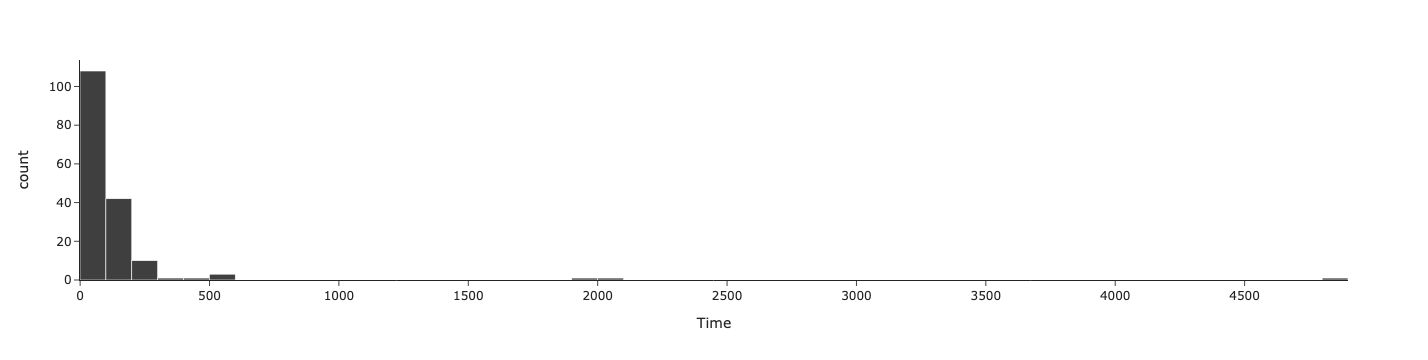

In [71]:
# We first check for normality
fig = px.histogram(df_sgl, x="Time", nbins=50, template='simple_white',
             color_discrete_sequence=['#3f3f3f'])
fig.write_image(os.path.join(path_study_data_results,
                             'distribution_all.pdf'), width=1000, height=300, scale=4)
fig

/var/folders/lt/rbb0s8nn4wzbjftxx8s6bqx40000gp/T/ipykernel_13066/460292619.py:3: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(path_study_data_results,


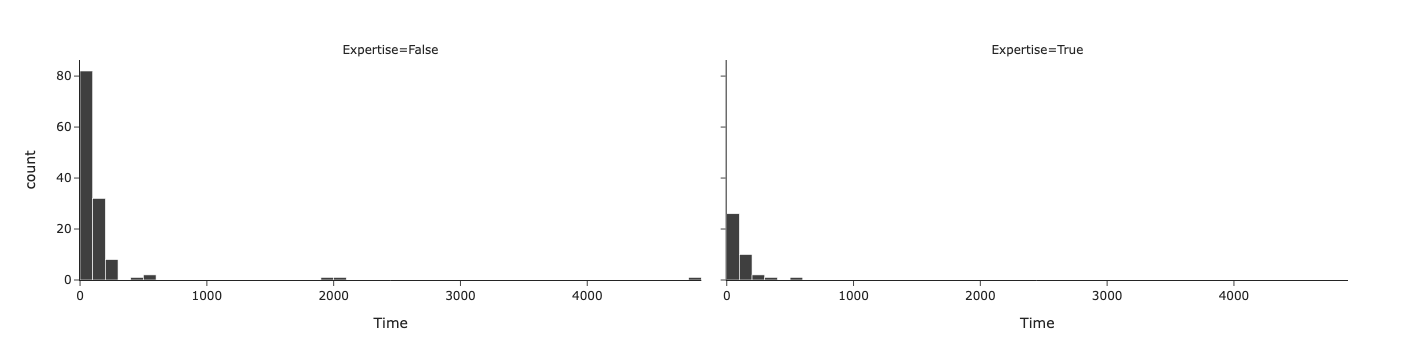

In [72]:
fig = px.histogram(df_sgl, x="Time", nbins=50, template='simple_white', facet_col='Expertise',
             color_discrete_sequence=['#3f3f3f'])
fig.write_image(os.path.join(path_study_data_results,
                             'distribution_stratified.pdf'), width=1000, height=300, scale=4)
fig

In [73]:
# It is not normal (we check it below), so we use mannwhitney test and
# rank-biserial correlation

In [74]:
def check_statistics(series_expert, series_novice):

    float_shapiro_expert_stat, float_shapiro_expert_p = stats.shapiro(
        series_expert)
    float_shapiro_novice_stat, float_shapiro_novice_p = stats.shapiro(
        series_novice)
    float_kolmogorov_expert_stat, float_kolmogorov_expert_p = stats.kstest(
        series_expert, 'norm')
    float_kolmogorov_novice_stat, float_kolmogorov_novice_p = stats.kstest(
        series_novice, 'norm')

    float_mann_statistic, float_mann_p_value = stats.mannwhitneyu(
        series_expert, series_novice, alternative='two-sided')

    # Calculate means
    mean_expert = series_expert.mean()
    mean_non_expert = series_novice.mean()

    # Calculate standard deviations
    std_expert = series_expert.std(ddof=1)  # Sample standard deviation
    std_non_expert = series_novice.std(ddof=1)

    # Sample sizes
    n_expert = len(series_expert)
    n_non_expert = len(series_novice)

    # Calculate pooled standard deviation
    pooled_std = np.sqrt(((n_expert - 1) * std_expert**2 + (n_non_expert - 1) * std_non_expert**2) / (n_expert + n_non_expert - 2))

    # Calculate rank-biserial correlation
    r = 1 - (2 * float_mann_statistic) / (n_expert * n_non_expert)

    # Print results
    print("Mean Expert:", mean_expert)
    print("Mean Non-Expert:", mean_non_expert)
    print("Pooled Standard Deviation:", pooled_std)
    print("Shapiro Expert: stat =", float_shapiro_expert_stat, "p =",
          float_shapiro_expert_p)
    print("Shapiro Non-Expert: stat =", float_shapiro_novice_stat, "p =",
          float_shapiro_novice_p)
    print("Kolmogorov Expert: stat =", float_kolmogorov_expert_stat, "p =",
          float_kolmogorov_expert_p)
    print("Kolmogorov Non-Expert: stat =", float_kolmogorov_novice_stat, "p =",
          float_kolmogorov_novice_p)
    print("Mann-Whitney U stat =", float_mann_statistic, "p =",
          float_mann_p_value)
    print("Rank-biserial correlation =", r)

    return None


    r < 0.3: small effect
    0.3 ≤ r < 0.5: medium effect
    r ≥ 0.5: large effect


In [75]:
# We calculate for both train and test tasks, and individually

check_statistics(df_expert['Time'], df_novice['Time'])

Mean Expert: 102.575
Mean Non-Expert: 158.4453125
Pooled Standard Deviation: 428.00974958062494
Shapiro Expert: stat = 0.7376645887868192 p = 4.283110854232464e-07
Shapiro Non-Expert: stat = 0.23484204014944476 p = 6.352356106715355e-23
Kolmogorov Expert: stat = 0.9999999999987201 p = 0.0
Kolmogorov Non-Expert: stat = 0.9999997133484281 p = 0.0
Mann-Whitney U stat = 2546.0 p = 0.9599010885357365
Rank-biserial correlation = 0.005468750000000022


In [76]:
check_statistics(df_expert_train['Time'], df_novice_train['Time'])

Mean Expert: 101.0
Mean Non-Expert: 147.609375
Pooled Standard Deviation: 527.0526797659562
Shapiro Expert: stat = 0.6529805465347827 p = 1.0979564594724059e-05
Shapiro Non-Expert: stat = 0.16891567340564806 p = 3.235763878697032e-17
Kolmogorov Expert: stat = 0.9999999999987201 p = 2.7817234264371405e-238
Kolmogorov Non-Expert: stat = 0.9999997133484281 p = 0.0
Mann-Whitney U stat = 639.5 p = 1.0
Rank-biserial correlation = 0.0007812499999999556


In [77]:
check_statistics(df_expert_test['Time'], df_novice_test['Time'])

Mean Expert: 104.15
Mean Non-Expert: 169.28125
Pooled Standard Deviation: 304.768394420755
Shapiro Expert: stat = 0.8974580271699865 p = 0.03696248532441735
Shapiro Non-Expert: stat = 0.3729570301850744 p = 4.711579520290425e-15
Kolmogorov Expert: stat = 0.9999999999987201 p = 2.7817234264371405e-238
Kolmogorov Non-Expert: stat = 1.0 p = 0.0
Mann-Whitney U stat = 651.0 p = 0.9121838766481385
Rank-biserial correlation = -0.01718749999999991


/var/folders/lt/rbb0s8nn4wzbjftxx8s6bqx40000gp/T/ipykernel_13066/2190210729.py:49: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(os.path.join(path_study_data_results,


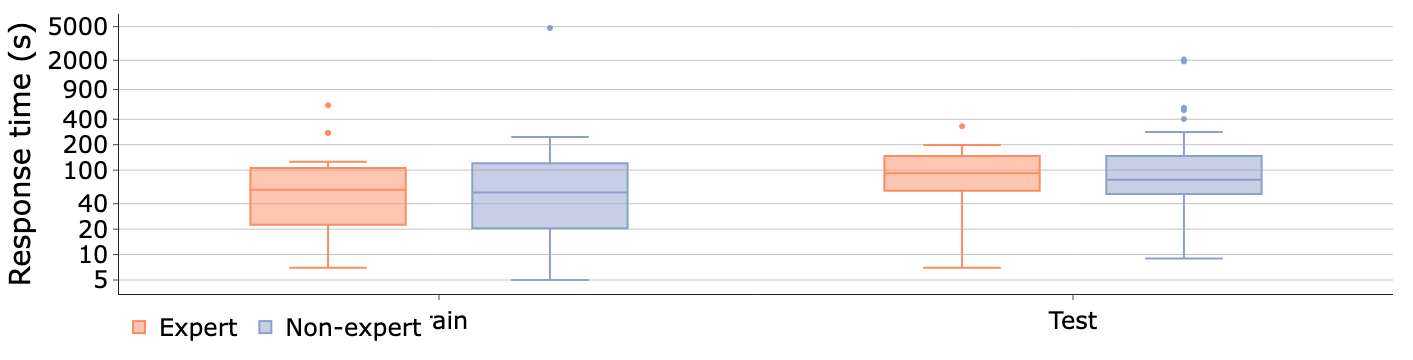

In [78]:
fig = go.Figure()
fig.add_trace(go.Box(
    y=df_expert["Time"],
    x=df_expert["Question"],
    name='Expert',
    marker_color='#FC8D62',
    # boxmean=True
))
fig.add_trace(go.Box(
    y=df_novice["Time"],
    x=df_novice["Question"],
    name='Non-expert',
    marker_color='#8DA0CB',
    # boxmean=True
))

fig.update_xaxes(showgrid=False,zeroline=True,)
fig.update_yaxes(type="log",
                 zeroline=True, zerolinewidth=1, zerolinecolor='#C3C3C3',
                 showgrid=True, gridcolor='#C3C3C3',
                 )
fig.update_layout(
    template='simple_white',
    #plot_bgcolor='rgba(0, 0, 0, 0)',
    #paper_bgcolor='rgba(0, 0, 0, 0)',
    width=500,  # Adjust width in pixels
    yaxis = dict(
        title='Response time (s)',
        tickvals = [0, 5, 10, 20, 40, 100, 200, 400, 900, 2000, 5000],
    ),
    font=dict(
        # family="Courier New, monospace",
        size=24,
        color="black"
        ),
    boxmode='group',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.2,
        xanchor="left",
        #x=1
    ),
    margin=dict(l=20, r=20, t=10, b=10),
)

fig.update_layout()

fig.write_image(os.path.join(path_study_data_results,
                             'time_box.pdf'))
fig.show(config= {'displaylogo': False})